# Missed Detection Risk Control
CRC and UCB monitors controlling the **missed detection rate**
R^II(λ) = P(∀t ≥ 1: s_t ≥ λ | y=0) instead of the false alarm rate.
Datasets: Mistral-qwen & Claude-qwen (math)

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom

cwd = Path().resolve()
root = next(
    (p for p in [cwd] + list(cwd.parents) if (p / 'src' / 'evaluator').is_dir()),
    None,
)
if root is None:
    raise RuntimeError(f'Could not find repo root from {cwd}.')
sys.path.insert(0, str(root / 'src'))
import evaluator as e_val

In [ ]:
# ── Method display names and colors ────────────────────────────────────────
NAMES = {
    'crc_cond': 'CRC (in expectation)',
    'crc_hp':   'CRC (high prob, HB)',
}

COLORS = {
    'crc_cond': 'seagreen',
    'crc_hp':   'crimson',
}

METHODS = list(NAMES.keys())

# ── Dataset paths (math) ─────────────────────────────────────────────────────
DATASETS = {
    'Mistral': '../output/factuality/merged_metadata/merged_Mistral-7B-Instruct-v0.3_qwen_all.csv',
    'Claude':  '../output/factuality/merged_metadata/merged_claude-haiku-4-5-20251001_qwen_all.csv',
}


# ── Evaluation hyperparameters ───────────────────────────────────────────────
ALPHAS    = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
DELTA_CRC = 0.1
DELTA     = 0.1
N_SPLITS  = 10
CAL_FRAC  = 0.2
BASE_SEED = 0

# ── Result paths (separate from FA-control results — do not overwrite) ───────
RESULTS_PATH      = '../output/factuality/monitor_performance/math_mistral_claude_seeds_md.json'

# ── Intermediate data caches ──────────────────────────────────────────────────
INT_PATH      = '../output/factuality/monitor_performance/math_series.csv'      

# ── Column names ─────────────────────────────────────────────────────────────
SCORE_COL   = 'judge_probability'
LABEL_COL   = 'solved'
PROBLEM_COL = 'uq_problem_idx'
STEP_COL    = 'num_steps'
TOKENS_COL  = 'generated_tokens'

DS_NAMES = {
    'Mistral': 'Mistral-7B-Instruct',
    'Claude':  'Claude Haiku 4.5',
}

METRIC_LABELS = {
    'fa':    r'False Alarm Rate ($\downarrow$)',
    'power': r'Power ($\uparrow$)',
    'frac':  r'Fraction of Tokens Saved',
    'delay': r'Detection Delay ($\downarrow$)',
}
COL_ORDER = ['fa', 'power', 'delay']

# Math

In [3]:
raw_data = {}
for name, path in DATASETS.items():
    df = pd.read_csv(path)
    df = df[df['label_valid']].reset_index(drop=True)
    df['solved']    = 1 - df['error_final_o3']
    df['num_steps'] = df['step_idx'] + 1
    df = e_val.utils.add_judge_probability_series(df)
    raw_data[name] = df
    print(f'{name}: {df.shape}, solved={df.groupby(PROBLEM_COL)[LABEL_COL].max().mean():.3f}')

Building judge_probability_series: 100%|██████████| 46721/46721 [01:10<00:00, 660.09it/s]


Mistral: (46721, 18), solved=0.133


Building judge_probability_series: 100%|██████████| 53980/53980 [01:21<00:00, 659.32it/s]

Claude: (53980, 18), solved=0.938


In [7]:
# ── CRC — Missed Detection (in-expectation) ─────────────────────────────────
def crc_class_cond_md(cal_df, test_df, alphas):
    """CRC min-score rule for missed detection rate (in-expectation bound).

    Controls R^II(λ) = P(∀t: s_t ≥ λ | y=0) ≤ α.
    Calibrates on unsolved (y=0) cal problems.
    MD bound = (#{unsolved cal with min_score ≥ λ} + 1) / (n_unsolved + 1).
    Since the bound DECREASES with λ, we take the SMALLEST λ where bound ≤ α
    (minimises false alarms while meeting the MD constraint).
    """
    cal_min = cal_df.groupby(PROBLEM_COL)[SCORE_COL].min()
    cal_y   = cal_df.groupby(PROBLEM_COL)[LABEL_COL].max().astype(int)
    n_uns   = int((cal_y == 0).sum())

    uns_mins = np.sort(cal_min[cal_y == 0].values)
    lam_grid = np.linspace(0.0, 1.0, 10001)

    # counts_md[i] = #{unsolved cal with min_score >= lam_grid[i]}
    counts_below = np.searchsorted(uns_mins, lam_grid, side='left')
    counts_md    = n_uns - counts_below
    bound        = (counts_md + 1.0) / (n_uns + 1.0)

    # bound decreases with λ → smallest λ where bound ≤ α
    lam_hat = {a: (float(lam_grid[bound <= a].min()) if (bound <= a).any() else None)
               for a in alphas}
    return _eval_threshold(test_df, lam_hat, alphas)


def _hb_pvalue_vec(counts, n, alpha):
    """Vectorised HB p-values for H0: E[L] > alpha over a grid of counts."""
    if n == 0:
        return np.ones(len(counts))
    r_hat = counts / n
    pvals = np.ones(len(counts))
    mask  = r_hat < alpha
    if not mask.any():
        return pvals
    r         = r_hat[mask]
    hoeffding = np.exp(-2 * n * (alpha - r) ** 2)
    k_alpha   = int(np.ceil(n * alpha))
    bentkus   = np.e * binom.sf(k_alpha - 1, n, r)
    pvals[mask] = np.minimum(hoeffding, bentkus)
    return pvals


def crc_class_cond_hp_md(cal_df, test_df, alphas, delta=DELTA_CRC):
    """CRC high-probability MD control (Hoeffding-Bentkus bound).

    Guarantees P(true MD rate > α) ≤ δ.
    Calibrates on unsolved problems; takes SMALLEST λ where HB p-value ≤ δ.
    """
    cal_min = cal_df.groupby(PROBLEM_COL)[SCORE_COL].min()
    cal_y   = cal_df.groupby(PROBLEM_COL)[LABEL_COL].max().astype(int)
    n_uns   = int((cal_y == 0).sum())

    uns_mins = np.sort(cal_min[cal_y == 0].values)
    lam_grid = np.linspace(0.0, 1.0, 10001)

    counts_below = np.searchsorted(uns_mins, lam_grid, side='left').astype(float)
    counts_md    = n_uns - counts_below

    lam_hat = {}
    for a in alphas:
        pvals = _hb_pvalue_vec(counts_md, n_uns, a)
        valid = pvals <= delta
        # bound decreases with λ → smallest λ where p-value ≤ δ
        lam_hat[a] = float(lam_grid[valid].min()) if valid.any() else None

    return _eval_threshold(test_df, lam_hat, alphas)


def _eval_threshold(test_df, lam_hat, alphas):
    """Evaluate power/FA/token-frac for per-alpha thresholds. Fully vectorised."""
    test_y        = test_df.groupby(PROBLEM_COL)[LABEL_COL].max().astype(int)
    solved_pids   = test_y[test_y == 1].index
    unsolved_pids = test_y[test_y == 0].index
    tokens_full   = test_df.groupby(PROBLEM_COL)[TOKENS_COL].sum()
    prob_min      = test_df.groupby(PROBLEM_COL)[SCORE_COL].min()

    unsolved_df = (
        test_df[test_df[PROBLEM_COL].isin(unsolved_pids)]
        .sort_values([PROBLEM_COL, STEP_COL])
        .copy()
    )
    unsolved_df['_cum_tok'] = unsolved_df.groupby(PROBLEM_COL)[TOKENS_COL].cumsum()

    power, fa, frac = [], [], []
    for a in alphas:
        lam = lam_hat[a]
        if lam is None:
            power.append(0.0); fa.append(0.0); frac.append(0.0)
            continue

        fa.append(float((prob_min[solved_pids] < lam).mean()) if len(solved_pids) > 0 else 0.0)

        below = unsolved_df[unsolved_df[SCORE_COL] < lam]
        if below.empty:
            power.append(0.0); frac.append(0.0)
            continue

        first_cum = below.groupby(PROBLEM_COL)['_cum_tok'].first()
        power.append(len(first_cum) / max(len(unsolved_pids), 1))

        tf    = tokens_full.loc[first_cum.index]
        valid = tf > 0
        fracs = (tf[valid] - first_cum[valid]) / tf[valid]
        frac.append(float(fracs.mean()) if len(fracs) > 0 else 0.0)

    return {'power': power, 'fa': fa, 'frac': frac}


def one_split_eval_md(df, seed, alphas=ALPHAS, delta_crc=DELTA_CRC):
    """One train/test split → CRC metrics under MD risk control."""
    unique_ids = df[PROBLEM_COL].unique()
    rng        = np.random.default_rng(seed)
    n_cal      = int(CAL_FRAC * len(unique_ids))
    cal_ids    = rng.choice(unique_ids, size=n_cal, replace=False)
    test_ids   = np.setdiff1d(unique_ids, cal_ids)

    cal_df  = df[df[PROBLEM_COL].isin(cal_ids)].reset_index(drop=True)
    test_df = df[df[PROBLEM_COL].isin(test_ids)].reset_index(drop=True)

    return {
        'crc_cond': crc_class_cond_md(cal_df, test_df, alphas),
        'crc_hp':   crc_class_cond_hp_md(cal_df, test_df, alphas, delta=delta_crc),
    }


def aggregate(split_results, methods=METHODS):
    """Mean, std, and 10/90% quantiles across splits for each method and metric."""
    agg = {}
    for m in methods:
        splits_with_m = [r[m] for r in split_results if m in r]
        if not splits_with_m:
            continue
        metrics = set(splits_with_m[0].keys())
        stacked = {
            metric: np.array([s[metric] for s in splits_with_m])
            for metric in metrics
        }
        agg[m] = {
            metric: {
                'mean': arr.mean(axis=0),
                'std':  arr.std(axis=0),
                'q10':  np.quantile(arr, 0.10, axis=0),
                'q90':  np.quantile(arr, 0.90, axis=0),
            }
            for metric, arr in stacked.items()
        }
    return agg

In [8]:
import json, os

# Load existing MD results if present; run missing seeds incrementally.
# Never writes to the FA-control seeds file (math_mistral_claude_seeds.json).
if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH) as f:
        all_results = json.load(f)
    print(f'Loaded existing MD results from {RESULTS_PATH}')
    for ds, splits in all_results.items():
        print(f'  {ds}: {len(splits)} splits already saved')
else:
    all_results = {}
    print(f'No existing MD results at {RESULTS_PATH} — starting from scratch.')

for ds_name, df in raw_data.items():
    if ds_name not in all_results:
        all_results[ds_name] = []

    n_done = len(all_results[ds_name])
    if n_done >= N_SPLITS:
        print(f'{ds_name}: already has {n_done} splits, skipping.')
        continue

    print(f'\n=== {ds_name}: running splits {n_done}..{N_SPLITS-1} ===')
    for i in range(n_done, N_SPLITS):
        print(f'  split {i}...', end=' ', flush=True)
        res = one_split_eval_md(df, seed=BASE_SEED + i)
        all_results[ds_name].append(res)
        print('done')

    # Save after each dataset so partial progress is preserved
    os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)
    with open(RESULTS_PATH, 'w') as f:
        json.dump(all_results, f, indent=2)
    print(f'Saved to {RESULTS_PATH}')

print('\nAll math splits complete.')

Loaded existing MD results from ../out/math_mistral_claude_seeds_md.json
  Mistral: 10 splits already saved
  Claude: 10 splits already saved
Mistral: already has 10 splits, skipping.
Claude: already has 10 splits, skipping.

All math splits complete.


In [9]:
import copy
import plotting_style

def add_delay(all_results_math):
    result = copy.deepcopy(all_results_math)
    for runs in result.values():
        for run in runs:
            for metrics in run.values():
                metrics['delay'] = (1 - np.asarray(metrics['frac'])).tolist()
    return result

In [10]:
def plot_figure_v2(agg_results, datasets_order, filename, methods,
                   power_ylim1=None, power_ylim2=None,
                   dd_lim1=None, dd_lim2=None,
                   band='quantile',
                   metric_labels=None,
                   alphas_arr=None):
    """
    band: 'std' for mean ± 1 std, 'quantile' for 10–90% band.
          'quantile' requires agg[method][metric] to contain 'q10' and 'q90'.
    methods: iterable of method keys to plot (replaces global METHODS).
    metric_labels: optional dict overriding METRIC_LABELS for column titles.

    Differences vs plot_figure:
      - power column shows 1 - power (band flipped accordingly)
      - identity reference line moved from 'fa' to 'power' column
      - methods passed in explicitly
      - metric_labels can be customised
    """
    if metric_labels is None:
        metric_labels = METRIC_LABELS

    n_rows = len(set(datasets_order) & set(DS_NAMES))

    fig, axes = plt.subplots(
        n_rows, len(COL_ORDER),
        figsize=(plotting_style.text_width, 1.55 * n_rows),
        sharex=True,
        squeeze=False,
    )

    row_idx = 0
    for ds_name in datasets_order:
        if ds_name not in DS_NAMES:
            print(f"Skipping {ds_name} (not in DS_NAMES)")
            continue
        agg = agg_results[ds_name]
        n = len(alphas_arr)

        for col_idx, metric in enumerate(COL_ORDER):
            ax = axes[row_idx, col_idx]

            for method in methods:
                if method not in agg:
                    continue
                d = agg[method][metric]
                mean = np.asarray(d['mean'])[:n]

                if band == 'quantile':
                    lo = np.asarray(d['q10'])[:n]
                    hi = np.asarray(d['q90'])[:n]
                else:  # 'std'
                    std = np.asarray(d['std'])[:n]
                    lo, hi = mean - std, mean + std

                # Flip power -> 1 - power (and swap band bounds accordingly)
                if metric == 'power':
                    mean = 1 - mean
                    lo, hi = 1 - hi, 1 - lo

                ax.plot(alphas_arr, mean, marker='o',
                        color=COLORS[method], label=NAMES[method], alpha=1)
                ax.fill_between(alphas_arr, lo, hi,
                                alpha=0.2, color=COLORS[method])

            # Identity line now lives in the power column
            if metric == 'power':
                ax.plot(alphas_arr, alphas_arr, '--', color='gray',
                        linewidth=1,
                        label=r'$\hat{\mathcal{R}}^{II}(\hat{\lambda}) = \epsilon$')

            ax.set_xlim(alphas_arr[0] - 0.02, alphas_arr[-1] + 0.02)
            ax.set_ylim(0, 1)

            if row_idx == 0:
                ax.set_title(metric_labels[metric])
            if col_idx == 0:
                ax.set_ylabel(DS_NAMES.get(ds_name, ds_name))
                ax.set_ylim(0, 0.6)
            if col_idx == 1 and row_idx == 0 and power_ylim1 is not None:
                ax.set_ylim(power_ylim1[0], power_ylim1[1])
            if col_idx == 1 and row_idx == 1 and power_ylim2 is not None:
                ax.set_ylim(power_ylim2[0], power_ylim2[1])
            if col_idx == 2 and row_idx == 0 and dd_lim1 is not None:
                ax.set_ylim(dd_lim1[0], dd_lim1[1])
            if col_idx == 2 and row_idx == 1 and dd_lim2 is not None:
                ax.set_ylim(dd_lim2[0], dd_lim2[1])
            if row_idx == n_rows - 1:
                ax.set_xlabel(r'$\epsilon$')
            if row_idx == 0 and col_idx == 1:
                ax.legend()

        row_idx += 1

    plt.savefig(filename)
    plt.show()

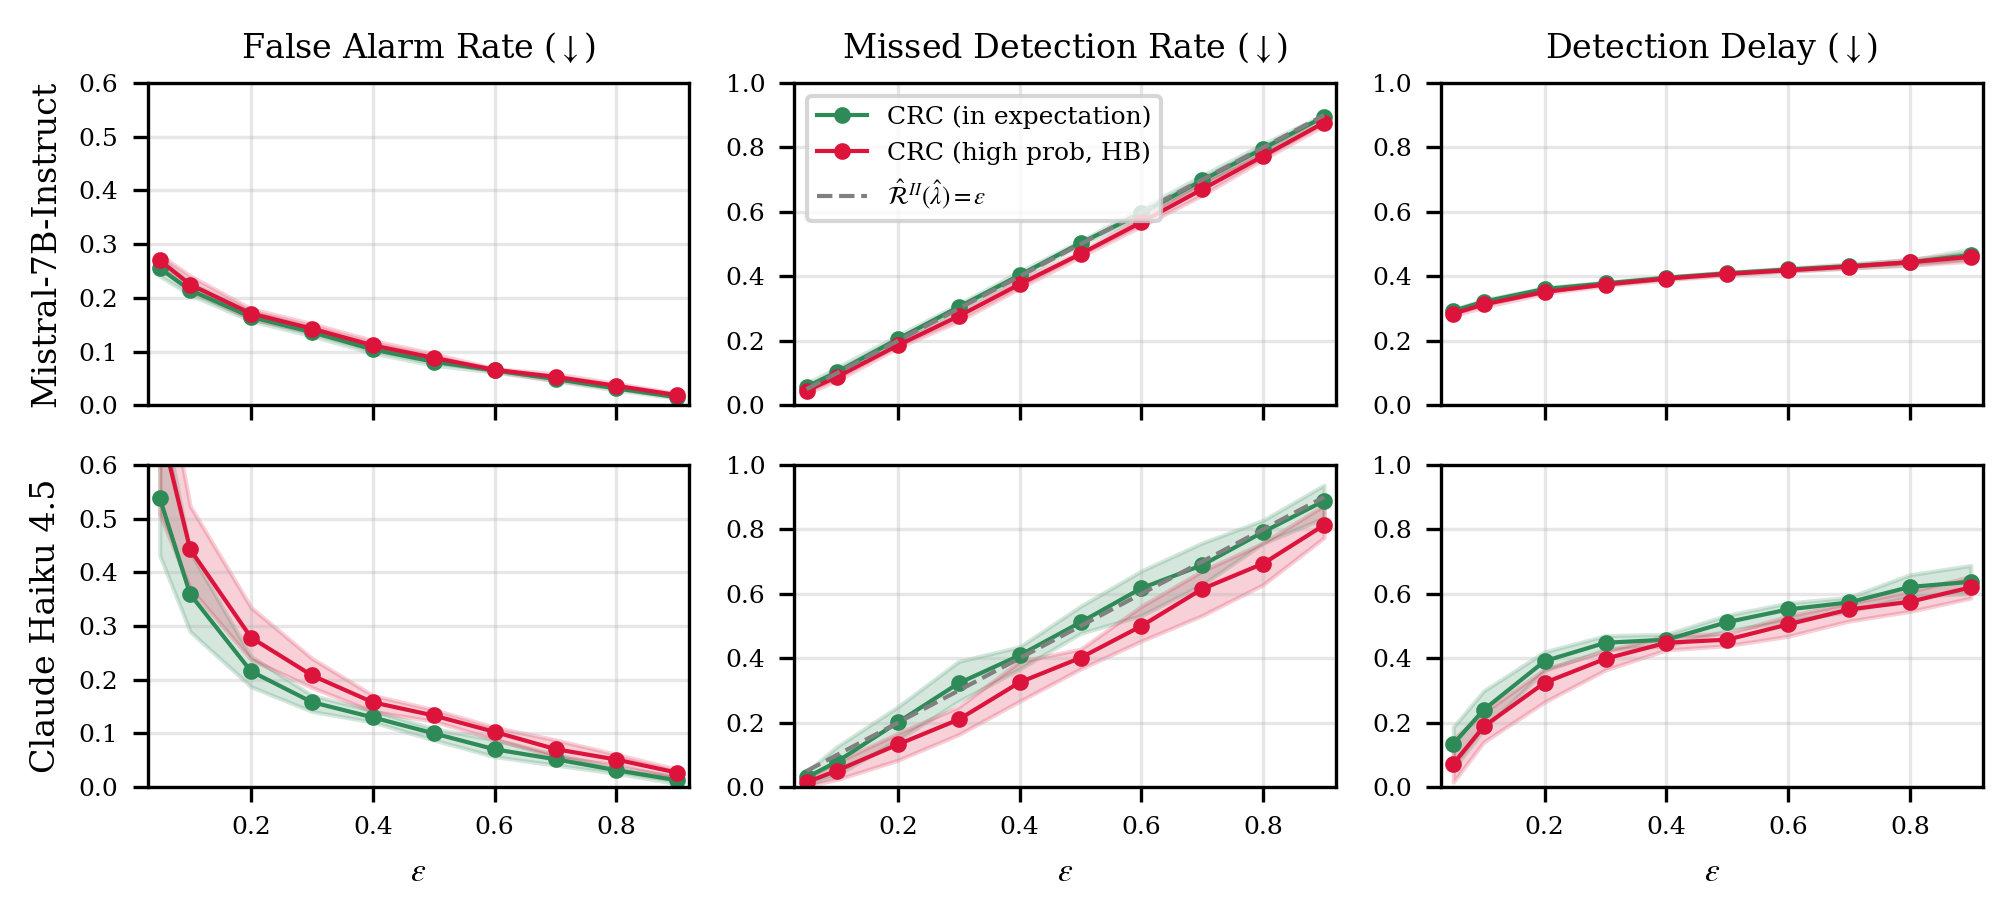

In [11]:
#RESULTS_PATH_MATH_MD = '../out/math_mistral_claude_seeds_md.json'

#with open(RESULTS_PATH_MATH_MD) as f:
#    all_results_math_md = json.load(f)

all_results = add_delay(all_results)
datasets_math_md    = list(all_results.keys())
agg_math_md         = {ds: aggregate(all_results[ds]) for ds in datasets_math_md}
alphas_arr = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

plot_figure_v2(
    agg_math_md,
    datasets_math_md,
    filename='../plots/monitors_compared_math_md.png',
    methods=['crc_cond', 'crc_hp'],
    alphas_arr=alphas_arr,
     metric_labels={                        # override column titles
        'fa':    r'False Alarm Rate ($\downarrow$)',
        'power': r'Missed Detection Rate ($\downarrow$)',  # relabelled from "Power" since we're plotting 1 - power
        'delay':    r'Detection Delay ($\downarrow$)',
    },
)